# py4conjoint — 全公開API デモ

このノートブックは `py4conjoint` の **全ユーザー向け関数・属性・メソッド** を
合成データで動作確認するためのものです。

| セクション | 内容 |
|:---:|------|
| 0 | セットアップ |
| 1 | 合成データの準備 |
| 2 | `pcr.forms_to_conjoint_data()` |
| 3 | `pcr.auto_reference_levels()` |
| 4 | `pcr.encode()` |
| 5 | `pcr.fit()` |
| 6 | `ConjointResult` のフィールド |
| 7 | `result.summary()` |
| 8 | `result.warnings()` |
| 9 | `result.importance()` |
| 10 | `result.wtp()` |
| 11 | `result.unit_rating_money()` |
| 12 | `result.market_share()` |
| 13 | 可視化（`plot_importance / plot_partworth / plot_wtp`） |

## 0. セットアップ

In [1]:
import numpy as np
import pandas as pd
import py4conjoint.rating as pcr

print(f"py4conjoint version: {pcr.__version__}")

py4conjoint version: 0.3.0


## 1. 合成データの準備

コンジョイント分析では **プロファイル** を回答者に提示し、各プロファイルを評価してもらいます。
ここでは価格・OS・カメラの 3 属性・各 2 水準（4 プロファイル）の設計を使用します。

| プロファイルID | price（万円） | os | camera |
|----------|:-----------:|:-----:|:------:|
| P1 | 6 | android | 標準 |
| P2 | 10 | apple | 標準 |
| P3 | 6 | apple | 高性能 |
| P4 | 10 | android | 高性能 |

`forms_to_conjoint_data()` の出力と同じ **long 形式**（1 行 = 1 人 × 1 プロファイル）を生成します。

想定する真の係数： `price_0 = +1.25`、`os_0 = +0.8`、`camera_0 = +0.6`

In [2]:
cards = pd.DataFrame(
    {
        "price":  [6, 10, 6, 10],
        "os":     ["android", "apple", "apple", "android"],
        "camera": ["標準", "標準", "高性能", "高性能"],
    },
    index=["P1", "P2", "P3", "P4"],
)

rng = np.random.default_rng(42)
rows = []
for resp_id in range(1, 31):          # 30 人
    for profile_id, (_, row) in zip(cards.index, cards.iterrows()):
        utility = (
            -1.25 * (1 if row["price"] == 10 else -1)
            + 0.80 * (1 if row["os"] == "apple" else -1)
            + 0.60 * (1 if row["camera"] == "高性能" else -1)
        )
        rating = int(round(utility * 2 + 5 + rng.normal(0, 0.3)))
        rating = max(1, min(7, rating))
        rows.append(
            {
                "回答者ID": resp_id,
                "プロファイルID": profile_id,
                "rating": rating,
                "price": row["price"],
                "os": row["os"],
                "camera": row["camera"],
            }
        )
df = pd.DataFrame(rows)

print(f"行数: {len(df)} = {df['回答者ID'].nunique()} 人 × {len(cards)} プロファイル")
df.head(8)

行数: 120 = 30 人 × 4 プロファイル


,回答者ID,プロファイルID,rating,price,os,camera
0,1,P1,5,6,android,標準
1,1,P2,3,10,apple,標準
2,1,P3,7,6,apple,高性能
3,1,P4,2,10,android,高性能
4,2,P1,4,6,android,標準
5,2,P2,3,10,apple,標準
6,2,P3,7,6,apple,高性能
7,2,P4,2,10,android,高性能


## 2. `pcr.forms_to_conjoint_data()` — アンケートファイルの読み込み

Microsoft Forms（.xlsx）または Google Forms（.csv）の回答ファイルを
**long 形式 DataFrame** に変換する関数です。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `responses_file` | str | — | アンケートファイルのパス（.xlsx / .csv） |
| `attributes` | DataFrame or dict | — | プロファイル設計（行：プロファイル、列：属性） |
| `n_profiles` | int | `None` | 提示したプロファイル枚数（省略時は attributes から自動推測） |
| `forms` | str | `"microsoft"` | `"microsoft"` または `"google"` |
| `respondent_cols` | dict | `None` | 回答者属性として残したい列の対応辞書 |
| `profile_id_prefix` | str | `"P"` | プロファイルIDの接頭辞（P1, P2, ...） |
| `rating_colname` | str | `"rating"` | 出力 DataFrame の評点列名 |
| `respondent_id_colname` | str | `"回答者ID"` | 出力 DataFrame の回答者 ID 列名 |
| `profile_id_colname` | str | `"プロファイルID"` | 出力 DataFrame のプロファイル ID 列名 |
| `out_csv` | str | `None` | 変換後 DataFrame を CSV で保存するパス |

**返り値**: long 形式 DataFrame（列：回答者ID, プロファイルID, rating, 回答者属性, プロファイル属性）

In [3]:
# このセルは実際のアンケートファイルが必要なため、そのまま実行しても
# FileNotFoundError になります。実際に使う場合は responses_file を
# 実際のファイルパスに書き換えてから実行してください。

# df_from_forms = pcr.forms_to_conjoint_data(
#     responses_file="responses.xlsx",   # Microsoft Forms の場合
#     attributes=cards,                  # DataFrame 形式（推奨）
#     n_profiles=4,                      # 省略可（cards の行数から自動推測）
#     forms="microsoft",                 # "google" も可
#     respondent_cols={"性別": "gender", "学年": "grade"},  # 回答者属性（任意）
#     profile_id_prefix="P",
#     rating_colname="rating",
#     respondent_id_colname="回答者ID",
#     profile_id_colname="プロファイルID",
#     out_csv="conjoint_data.csv",       # CSV 保存（任意）
# )

# attributes は辞書形式でも指定できる
# df_from_forms = pcr.forms_to_conjoint_data(
#     responses_file="responses.xlsx",
#     attributes={
#         "price":  [6, 10, 6, 10],
#         "os":     ["android", "apple", "apple", "android"],
#         "camera": ["標準", "標準", "高性能", "高性能"],
#     },
# )

print("forms_to_conjoint_data() の使い方はコメントを参照してください。")
print("このノートブックでは合成データ df をそのまま使います。")

forms_to_conjoint_data() の使い方はコメントを参照してください。
このノートブックでは合成データ df をそのまま使います。


## 3. `pcr.auto_reference_levels()` — 基準水準の自動推測

各属性の基準水準（`encode()` で `-1` になる水準）を自動で推測する補助関数です。

**判定ルール**
- 数値列（価格相当）: **最大値** を基準
- カテゴリ列: 文字列で辞書順ソートして **先頭** を基準

⚠️ 推論ベースなので、内容を確認してから `encode()` に渡してください。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | 属性列を含む DataFrame |
| `attribute_columns` | list of str | — | 基準水準を推測したい属性名リスト |
| `price_columns` | list of str | `["price"]` | 価格相当の列名（最大値を基準にする） |

**返り値**: `dict` — そのまま `encode()` の `reference_levels` に渡せる

In [4]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    auto_refs = pcr.auto_reference_levels(
        df,
        attribute_columns=["price", "os", "camera"],
        price_columns=["price"],   # 価格列を明示（最大値を基準にする）
    )

print("自動推測された基準水準:")
for attr, ref in auto_refs.items():
    print(f"  {attr}: {ref!r}")

if caught:
    print(f"\n[警告メッセージ]\n{caught[0].message}")

自動推測された基準水準:
  price: 10
  os: 'android'
  camera: '標準'

[警告メッセージ]
基準水準を自動で推測しました（推論ベース）。
結果を確認し、必要なら明示的に reference_levels を指定してください。
  price: 10 （数値・価格列なので最大値）
  os: 'android' （カテゴリ列なので辞書順で先頭）
  camera: '標準' （カテゴリ列なので辞書順で先頭）


## 4. `pcr.encode()` — 効果コーディング（-1 / +1）

属性列を **効果コーディング（±1）** に自動変換する関数です。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | long 形式のデータ |
| `reference_levels` | dict | — | `{"属性名": 基準水準}` の辞書。基準水準が `-1` になる |
| `respondent_encode` | dict | `None` | 回答者属性を 0/1 にコード化したい場合に指定。`{"列名": "0にする水準"}` または `{"列名": ["0にする水準", "サフィックス"]}` |
| `binary_suffix_map` | dict | `None` | 2 水準属性の列名サフィックスを手動指定 |
| `drop_original` | bool | `False` | 元の属性列を削除するか |
| `inplace` | bool | `False` | 入力 df を直接書き換えるか |

**返り値の列名ルール**
- 2 水準 → `{属性名}_0` が 1 列追加
- 3 水準以上 → `{属性名}_0`, `{属性名}_1`, … が K-1 列追加
- `binary_suffix_map` 指定時 → `{属性名}_{指定サフィックス}`
- `respondent_encode` 指定時 → `{回答者属性}_{サフィックス}`

In [5]:
# 基本的な使い方
df_coded = pcr.encode(
    df,
    reference_levels={
        "price":  10,        # 高い方を基準 → 安い方(6万)が +1
        "os":     "android",
        "camera": "標準",
    },
)

added_cols = [c for c in df_coded.columns if c not in df.columns]
print("追加された符号化列:", added_cols)
df_coded[["回答者ID", "プロファイルID", "rating", "price_0", "os_0", "camera_0"]].head(8)

追加された符号化列: ['price_0', 'os_0', 'camera_0']


,回答者ID,プロファイルID,rating,price_0,os_0,camera_0
0,1,P1,5,1,-1,-1
1,1,P2,3,-1,1,-1
2,1,P3,7,1,1,1
3,1,P4,2,-1,-1,1
4,2,P1,4,1,-1,-1
5,2,P2,3,-1,1,-1
6,2,P3,7,1,1,1
7,2,P4,2,-1,-1,1


In [6]:
# binary_suffix_map: 列名のサフィックスを手動指定
df_named = pcr.encode(
    df,
    reference_levels={"price": 10, "os": "android", "camera": "標準"},
    binary_suffix_map={"price": "low", "os": "apple", "camera": "high"},
)
print("binary_suffix_map 指定時の列名:",
      [c for c in df_named.columns if c not in df.columns])

binary_suffix_map 指定時の列名: ['price_low', 'os_apple', 'camera_high']


/var/folders/_f/g_05tt3j09n5hcrk1mwhyj5r0000gn/T/ipykernel_26170/3126776209.py:2: DeprecationWarning: binary_suffix_map は非推奨です。suffix_map を使ってください。
例: suffix_map={'price': 'low', 'os': 'apple'}
  df_named = pc.encode(


In [7]:
# drop_original=True: 元の属性列を削除
df_dropped = pcr.encode(
    df,
    reference_levels={"price": 10, "os": "android", "camera": "標準"},
    drop_original=True,
)
print("drop_original=True 後の列:", list(df_dropped.columns))

drop_original=True 後の列: ['回答者ID', 'プロファイルID', 'rating', 'price_0', 'os_0', 'camera_0']


In [8]:
# inplace=True: 入力 df を直接書き換える（コピーを返さない）
df_copy = df.copy()
result_inplace = pcr.encode(
    df_copy,
    reference_levels={"price": 10, "os": "android", "camera": "標準"},
    inplace=True,
)
print("inplace=True: 戻り値は元の df と同一オブジェクト:",
      result_inplace is df_copy)
print("追加列:", [c for c in df_copy.columns if c not in df.columns])

inplace=True: 戻り値は元の df と同一オブジェクト: True
追加列: ['price_0', 'os_0', 'camera_0']


In [9]:
# 3 水準以上の属性：K-1 列が生成される
df_multi = pd.DataFrame(
    {
        "rating": [5, 3, 7, 4, 6, 2],
        "color":  ["赤", "青", "緑", "赤", "青", "緑"],
    }
)
df_multi_coded = pcr.encode(
    df_multi,
    reference_levels={"color": "赤"},  # 3 水準 → color_0（青）, color_1（緑）
)
print("3 水準属性の符号化（基準=赤）:")
print(df_multi_coded)

3 水準属性の符号化（基準=赤）:
   rating color  color_0  color_1
0       5     赤       -1       -1
1       3     青        1        0
2       7     緑        0        1
3       4     赤       -1       -1
4       6     青        1        0
5       2     緑        0        1


## 5. `pcr.fit()` — OLS 回帰

符号化済み DataFrame に OLS 回帰を適用し、`ConjointResult` を返す関数です。
欠損値の除外、日本語列名の自動エイリアス処理、落とし穴チェックを自動実行します。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | `encode()` 済みの DataFrame |
| `rating` | str | `"rating"` | 評点（被説明変数）の列名 |
| `price_col` | str | `"price"` | 価格列名。WTP 計算で使用 |
| `encoded_columns` | list of str | `None` | 説明変数リスト（省略時は自動検出） |
| `reference_levels` | dict | `None` | 基準水準辞書（`encode()` 経由なら自動取得） |
| `formula` | str | `None` | statsmodels 用の回帰式を直接指定 |
| `respondent_id_col` | str | `"回答者ID"` | 回答者ID列名（クラスタロバスト標準誤差と回答者数診断に使用） |
| `cluster_se` | bool | `True` | 回答者IDによるクラスタロバスト標準誤差を使用（係数は不変、p値が適正化） |

**返り値**: `ConjointResult` オブジェクト

In [10]:
# 基本的な使い方（encode() 後は reference_levels が df.attrs に保存されている）
result = pcr.fit(df_coded, price_col="price")
print("fit() 完了")

fit() 完了


In [11]:
# encoded_columns を明示的に指定する例
result_explicit = pcr.fit(
    df_coded,
    encoded_columns=["price_0", "os_0", "camera_0"],
    price_col="price",
)
print("encoded_columns 明示指定でも同じ係数が得られる:")
print(result_explicit.params)

encoded_columns 明示指定でも同じ係数が得られる:
Intercept    4.175000
price_0      1.708333
os_0         0.791667
camera_0     0.325000
dtype: float64


## 6. `ConjointResult` のフィールド

### 6-A. プロパティ（頻繁に使う）

| プロパティ | 型 | 説明 |
|-----------|-----|------|
| `params` | `pd.Series` | 推定係数（切片含む） |
| `rsquared` | `float` | 決定係数 R² |
| `n_obs` | `int` | 分析に使用した観測数 |
| `intercept` | `float` | 切片 b₀（全水準平均の効用） |

### 6-B. データフィールド（中級者向け）

| フィールド | 型 | 説明 |
|-----------|-----|------|
| `rating` | `str` | 評点列名 |
| `encoded_columns` | `list` | 説明変数（符号化列）のリスト |
| `reference_levels` | `dict` | `encode()` に渡された基準水準辞書 |
| `price_col` | `str` | 価格列名 |
| `n_dropped` | `int` | 欠損除外された行数 |
| `alias_map` | `dict` | 符号化列名の内部エイリアスマップ（`formula=None` 時に生成、内部処理用） |
| `ols` | `RegressionResults` | statsmodels の生の推定結果 |

In [12]:
# プロパティ
print("result.params")
print(result.params)
print()
print(f"result.rsquared  = {result.rsquared:.4f}")
print(f"result.n_obs     = {result.n_obs}")
print(f"result.intercept = {result.intercept:.4f}")

result.params
Intercept    4.175000
price_0      1.708333
os_0         0.791667
camera_0     0.325000
dtype: float64

result.rsquared  = 0.9838
result.n_obs     = 120
result.intercept = 4.1750


In [13]:
# データフィールド
print(f"result.rating            = {result.rating!r}")
print(f"result.encoded_columns   = {result.encoded_columns}")
print(f"result.reference_levels  = {result.reference_levels}")
print(f"result.price_col         = {result.price_col!r}")
print(f"result.n_dropped         = {result.n_dropped}")
print(f"result.alias_map         = {result.alias_map}")

result.rating            = 'rating'
result.encoded_columns   = ['price_0', 'os_0', 'camera_0']
result.reference_levels  = {'price': 10, 'os': 'android', 'camera': '標準'}
result.price_col         = 'price'
result.n_dropped         = 0
result.alias_map         = {'price_0': '__pc_var_0__', 'os_0': '__pc_var_1__', 'camera_0': '__pc_var_2__'}


In [14]:
# ols: statsmodels の RegressionResults をそのまま利用
print(result.ols.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     558.8
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           6.97e-24
Time:                        21:42:18   Log-Likelihood:                -1.7451
No. Observations:                 120   AIC:                             11.49
Df Residuals:                     116   BIC:                             22.64
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.1750      0.022    193.759      0.0

/Users/tetsu/.cache/uv/archive-v0/MVEytwRFAGqC9bcpZk5RJ/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


## 7. `result.summary()` — 和文サマリー

係数表・R²・落とし穴チェック結果を **日本語** でまとめて表示します。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `slim` | bool | `True` | `True` → コンパクトな係数表、`False` → statsmodels 標準の詳細表 |

**返り値**: `str` — 重大度「大」の落とし穴のみ表示（「中」「小」は `warnings()` で確認）

In [15]:
# slim=True（デフォルト）
print(result.summary())

コンジョイント分析の結果（和文サマリー）
観測数        : 120
説明変数の数  : 3
決定係数 R²   : 0.9838
自由度修正 R² : 0.9833
標準誤差      : クラスタロバスト（回答者ID）

【推定された係数（部分効用 part-worth）】
  変数                            係数        p値  有意性
  ------------------------- ---------- ----------  ------
  Intercept                     4.1750     0.0000  ***
  price_0                       1.7083     0.0000  ***
  os_0                          0.7917     0.0000  ***
  camera_0                      0.3250     0.0000  ***

  有意水準: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1


In [16]:
# slim=False: statsmodels の詳細な統計表（英語）を表示
print(result.summary(slim=False))

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     558.8
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           6.97e-24
Time:                        21:42:18   Log-Likelihood:                -1.7451
No. Observations:                 120   AIC:                             11.49
Df Residuals:                     116   BIC:                             22.64
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.1750      0.022    193.759      0.0

## 8. `result.warnings()` — 落とし穴チェック

回帰分析で自動検出された **落とし穴（診断警告）** の一覧を返します。

**自動検出される警告の種類**

| カテゴリ | 重大度 | 検出タイミング | 内容 |
|----------|:------:|:-----------:|------|
| `r2_low` | 大 | `fit()` 直後 | R² < 0.20 |
| `obs_per_predictor` | 大/中 | `fit()` 直後 | 観測数／説明変数数の比率が低い（< 5 → 大、< 10 → 中） |
| `few_respondents` | 大/中 | `fit()` 直後 | 回答者数が少ない（1人 → 大、2〜4人 → 中、5人以上は警告なし） |
| `independence_assumed` | 中 | `fit()` 直後 | 回答者ID列が無く、観測の独立性を仮定した標準誤差を使用（p値が過小になる恐れ） |
| `price_sign_negative` | 中 | `fit()` 直後 | 価格係数の符号が逆かつ有意（価格↑で評点↑） |
| `price_insignificant` | 中 | `wtp()` 呼出時 | 価格の p 値 ≥ 0.10（3水準以上は同時F検定） |
| `wtp_extrapolation` | 中 | `wtp()` 呼出時 | \|WTP\| > 価格レンジ × 2 |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `severity` | str / list | `None` | 重大度でフィルタ（`"大"`/`"中"`/`"小"`） |
| `category` | str / list | `None` | カテゴリ名でフィルタ |
| `as_dataframe` | bool | `True` | `True` → DataFrame、`False` → `Diagnostic` リスト |

**返り値**: `pd.DataFrame`（列: severity, category, message, recommendation）または `list[Diagnostic]`

In [17]:
# --- 正常なデータ（30 人分）では警告なし ---

# wtp() を先に呼んで価格関連の警告も生成させる
_ = result.wtp()

print("【すべての警告】")
all_warnings = result.warnings()
if len(all_warnings) == 0:
    print("  警告なし（データ品質は良好）")
else:
    print(all_warnings.to_string(index=False))

【すべての警告】
  警告なし（データ品質は良好）


In [18]:
# --- 問題のあるデータ（3 人分・純ランダム評点）で警告をデモ ---

rng_bad = np.random.default_rng(99)
rows_bad = []
for resp_id in range(1, 4):                 # 3 人のみ
    for profile_id, (_, row) in zip(cards.index, cards.iterrows()):
        rows_bad.append(
            {
                "回答者ID": resp_id,
                "プロファイルID": profile_id,
                "rating":  int(rng_bad.integers(1, 8)),  # ランダム評点
                "price":   row["price"],
                "os":      row["os"],
                "camera":  row["camera"],
            }
        )
df_bad = pd.DataFrame(rows_bad)
df_bad_coded = pcr.encode(
    df_bad,
    reference_levels={"price": 10, "os": "android", "camera": "標準"},
)
result_bad = pcr.fit(df_bad_coded, price_col="price")
_ = result_bad.wtp()

print("【問題データの警告一覧】")
bad_warnings = result_bad.warnings()
if len(bad_warnings) == 0:
    print("  警告なし")
else:
    for _, row in bad_warnings.iterrows():
        print(f"  [{row['severity']}] {row['category']}")
        print(f"    {row['message']}")

【問題データの警告一覧】
  [大] r2_low
    R² = 0.059 が 0.20 未満で、説明力が低いです。
  [大] obs_per_predictor
    観測数（12）が説明変数数（3）の4.0倍しかなく、推定が非常に不安定です。
  [中] few_respondents
    回答者が 3 人と少なめです。推定値の不確実性が大きい点に注意してください。
  [中] price_insignificant
    価格係数（p値 = 0.575）が有意水準 0.10 を超えています。WTP の計算は価格係数を分母に使うため、係数が不確実だと WTP の信頼性も低くなります。


In [19]:
# severity でフィルタ
print("【重大度 '大' のみ】")
print(result_bad.warnings(severity="大"))

# category でフィルタ
print("\n【カテゴリ 'few_respondents' のみ】")
print(result_bad.warnings(category="few_respondents"))

# as_dataframe=False で Diagnostic オブジェクトのリストとして取得
print("\n【as_dataframe=False: Diagnostic リスト】")
diag_list = result_bad.warnings(as_dataframe=False)
for d in diag_list:
    print(f"  severity={d.severity!r}, category={d.category!r}")
    print(f"    message: {d.message[:60]}...")
    print(f"    recommendation: {d.recommendation[:60]}...")

【重大度 '大' のみ】
  severity           category                                 message  \
0        大             r2_low         R² = 0.059 が 0.20 未満で、説明力が低いです。   
1        大  obs_per_predictor  観測数（12）が説明変数数（3）の4.0倍しかなく、推定が非常に不安定です。   

                                      recommendation  
0  「評点 = 属性の足し算」という線形仮定が当てはまりにくい、または回答にノイズが多い可能性が...  
1          回答者を増やしてください。目安として観測数は説明変数数の10倍以上が望ましいです。  

【カテゴリ 'few_respondents' のみ】
  severity         category                                 message  \
0        中  few_respondents  回答者が 3 人と少なめです。推定値の不確実性が大きい点に注意してください。   

                              recommendation  
0  可能ならばさらに回答を集めてください。目安として最低でも10人以上が望ましいです。  

【as_dataframe=False: Diagnostic リスト】
  severity='大', category='r2_low'
    message: R² = 0.059 が 0.20 未満で、説明力が低いです。...
    recommendation: 「評点 = 属性の足し算」という線形仮定が当てはまりにくい、または回答にノイズが多い可能性があります。回答の質、属性の選...
  severity='大', category='obs_per_predictor'
    message: 観測数（12）が説明変数数（3）の4.0倍しかなく、推定が非常に不安定です。...
    recommendation: 回答者を増やしてください

## 9. `result.importance()` — 重要度

各属性の **効用範囲（最大 − 最小）の比率** として重要度を計算します。

**計算式**
$$\text{importance}_i = \frac{\text{range}_i}{\sum_j \text{range}_j} \times 100$$

2 水準の場合の効用範囲 = `2 × |係数|`（水準が -1 と +1 なので差は 2 倍）

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `as_percent` | bool | `True` | `True` → 合計 100%、`False` → 合計 1.0 の比率 |

**返り値**: `pd.DataFrame`（インデックス: 属性名、列: `効用範囲`, `重要度`）

In [20]:
print("【as_percent=True（デフォルト）— 合計 100%】")
imp_pct = result.importance(as_percent=True)
print(imp_pct)
print(f"  合計: {imp_pct['重要度'].sum():.1f}%")

print()
print("【as_percent=False — 合計 1.0 の比率】")
imp_ratio = result.importance(as_percent=False)
print(imp_ratio)
print(f"  合計: {imp_ratio['重要度'].sum():.4f}")

【as_percent=True（デフォルト）— 合計 100%】
            効用範囲        重要度
属性                         
price   3.416667  60.471976
os      1.583333  28.023599
camera  0.650000  11.504425
  合計: 100.0%

【as_percent=False — 合計 1.0 の比率】
            効用範囲       重要度
属性                        
price   3.416667  0.604720
os      1.583333  0.280236
camera  0.650000  0.115044
  合計: 1.0000


## 10. `result.wtp()` — WTP（限界支払意思額）

各非価格属性の **WTP（Willingness to Pay）** を計算します。
「基準水準から非基準水準に変えるとき、回答者が最大いくら追加で支払うか」を金額で表します。

**計算式**
$$\text{WTP}_{\text{attr}} = \underbrace{\frac{\text{price\_range}}{b_{\text{price}}}}_{\text{wtp\_price\_factor}} \times b_{\text{attr}}$$

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `price_col` | str | `None` | 価格列名（省略時は `fit()` の設定値） |

**返り値**: `pd.DataFrame`（インデックス: 符号化列名、列: `係数`, `限界支払意思額`）  
価格列と同じ単位（万円・千円・円など）で返されます。

In [21]:
wtp_df = result.wtp()
print(wtp_df)

# attrs に保存されたメタ情報も確認
print(f"\n  price_range      = {wtp_df.attrs['price_range']}")
print(f"  wtp_price_factor = {wtp_df.attrs['wtp_price_factor']:.4f}")
print(f"  p_price          = {wtp_df.attrs['p_price']:.4f}")

                 係数   限界支払意思額
属性（符号化列名）                    
os_0       0.791667  1.853659
camera_0   0.325000  0.760976

  price_range      = 4.0
  wtp_price_factor = 2.3415
  p_price          = 0.0000


### 価格3水準以上：区間別 WTP

価格を符号化すると各価格水準の効用が独立に推定されます。価格が **3水準以上**
のときは、隣接する価格水準の **区間ごと** に別々の傾き（価格感応度）で WTP を
計算します（`method="segment"`、デフォルト）。返り値には `価格区間` 列が付きます。

- 価格は **数値列** を `price_col` で指定し、符号化列（`price_low` など）は
  `encode()` が作って `encoded_columns` に入ります（rating / choice 共通ルール）。
- `method="linear"` を指定すると、従来どおり線形近似1本の単一値になります
  （`wtp_price_linear_approx` 警告はこのときだけ出ます）。
- 特定区間だけ見たいときは `price_segment="6〜8"`（または `(6, 8)`）。

In [ ]:
# --- 価格3水準での区間別 WTP ----------------------------------------
# 価格は「数値列」を price_col で指定し、符号化列（price_low など）は
# encode() が作って encoded_columns に入れる（rating / choice 共通ルール）。
rng3 = np.random.default_rng(0)
rows3 = []
for r in range(1, 31):
    for price in [6, 8, 10]:
        for cam in ["標準", "高性能"]:
            u = 4.0 + {6: 1.5, 8: 1.0, 10: -1.5}[price]   # 8→10 で急に下がる
            u += 0.8 if cam == "高性能" else -0.8
            u += rng3.normal(0, 0.3)
            rows3.append({"回答者ID": r, "rating": int(np.clip(round(u), 1, 7)),
                          "price": price, "camera": cam})
df3 = pd.DataFrame(rows3)

coded3 = pcr.encode(df3, reference_levels={"price": 10, "camera": "標準"},
                    suffix_map={"price": ["low", "mid"]})
res3 = pcr.fit(coded3, price_col="price")    # price_col には「数値列名」を渡す

print("■ 区間別 WTP（デフォルト method='segment'）")
print(res3.wtp())
print("\n■ 線形近似1本（method='linear'・従来方式）")
print(res3.wtp(method="linear"))

## 11. `result.unit_rating_money()` — 評点 1 点の金額換算

評点 1 ポイントが何円（または何万円）に相当するかを返します。

**計算式**
$$\text{unit\_rating\_money} = \frac{\text{price\_range}}{|b_{\text{price}}| \times 2}$$

効果コーディングで価格変数の範囲が `-1` 〜 `+1` の 2 単位であることに由来します。  
WTP の `wtp_price_factor`（= price_range / b_price）とは **異なる値** です（2 倍の差）。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `price_col` | str | `None` | 価格列名（省略時は `fit()` の設定値） |

**返り値**: `float` — 価格列と同じ単位

In [22]:
unit = result.unit_rating_money()
print(f"評点 1 点 = {unit:.4f} 万円")

# 手計算で確認
b_price = result.params["price_0"]
price_range = 10 - 6
print(f"検算: {price_range} / (|{b_price:.4f}| × 2) = {price_range / abs(b_price * 2):.4f}")

# wtp_price_factor との関係
print(f"\nwtp_price_factor = {wtp_df.attrs['wtp_price_factor']:.4f}")
print(f"unit_rating_money = wtp_price_factor / 2 = {wtp_df.attrs['wtp_price_factor'] / 2:.4f}")

評点 1 点 = 1.1707 万円
検算: 4 / (|1.7083| × 2) = 1.1707

wtp_price_factor = 2.3415
unit_rating_money = wtp_price_factor / 2 = 1.1707


## 12. `result.market_share()` — 市場シェア予測

複数製品の効用を推定し、市場シェアを予測します。

**計算方法**

| `method` | 説明 |
|----------|------|
| `"logit"`（デフォルト） | ソフトマックス型。`share_i = exp(u_i) / Σ exp(u_j)` |
| `"share_of_preference"` | `"logit"` の別名（同じ計算） |
| `"max"` | 最大効用ルール。最も効用が高い製品にシェア 1.0 |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `products` | DataFrame | — | 製品 × 符号化列の DataFrame |
| `method` | str | `"logit"` | `"logit"` / `"share_of_preference"` または `"max"` |

**返り値**: `pd.Series`（インデックス: 製品名、値: シェア 0〜1）  
合計は必ず 1.0 になります。

In [23]:
products = pd.DataFrame(
    {
        "price_0":  [ 1, -1,  1],   # 6万円=1, 10万円=-1
        "os_0":     [ 1,  1, -1],   # apple=1, android=-1
        "camera_0": [ 1,  1, -1],   # 高性能=1, 標準=-1
    },
    index=["製品A（6万・apple・高性能）", "製品B（10万・apple・高性能）", "製品C（6万・android・標準）"],
)

print('【method="logit"（デフォルト）】')
share_logit = result.market_share(products, method="logit")
print(share_logit)
print(f"  合計: {share_logit.sum():.6f}")

print()
print('【method="max"（最大効用ルール）】')
share_max = result.market_share(products, method="max")
print(share_max)
print(f"  合計: {share_max.sum():.6f}")

【method="logit"（デフォルト）】
製品A（6万・apple・高性能）     0.877199
製品B（10万・apple・高性能）    0.028791
製品C（6万・android・標準）    0.094010
Name: market_share, dtype: float64
  合計: 1.000000

【method="max"（最大効用ルール）】
製品A（6万・apple・高性能）     1.0
製品B（10万・apple・高性能）    0.0
製品C（6万・android・標準）    0.0
Name: market_share, dtype: float64
  合計: 1.000000


## 13. 可視化

3 つの可視化関数はいずれも **`result.plot_*()`** （ConjointResult メソッド）と
**`pcr.plot_*()`**（モジュールレベル関数）の 2 通りで呼び出せます。

すべて `matplotlib.axes.Axes` を返すので `ax.set_title()` 等で後から調整できます。

| 関数/メソッド | 主な引数 | 説明 |
|---|---|---|
| `plot_importance()` | `sort`, `show_values`, `color` | 重要度の水平棒グラフ |
| `plot_partworth()` | `show_zero_line` | 各水準の部分効用グラフ（属性ごとに色分け） |
| `plot_wtp()` | `sort`, `show_values`, `price_unit` | WTP の水平棒グラフ |

Text(0.5, 7.02222222222222, '重要度 (%)')

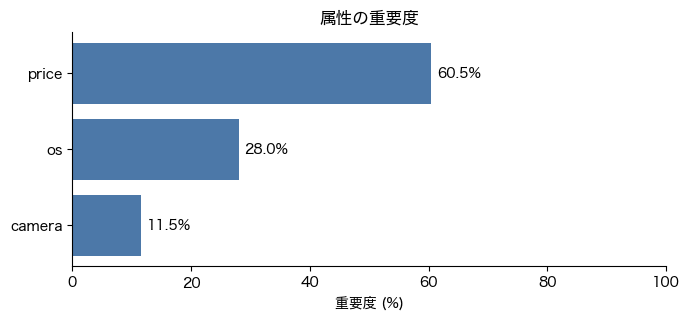

In [24]:
# plot_importance — result メソッドとして呼ぶ
ax = result.plot_importance(title="属性の重要度", show_values=True, sort=True)
ax.set_xlabel("重要度 (%)")

Text(0.5, 1.0, 'pc.plot_importance() で描画（ソートなし）')

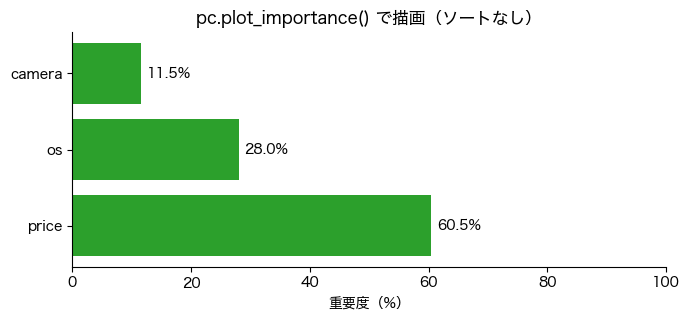

In [25]:
# plot_importance — pc モジュールの関数として呼ぶ（結果は同じ）
ax = pcr.plot_importance(result, color="#2CA02C", sort=False)
ax.set_title("pcr.plot_importance() で描画（ソートなし）")

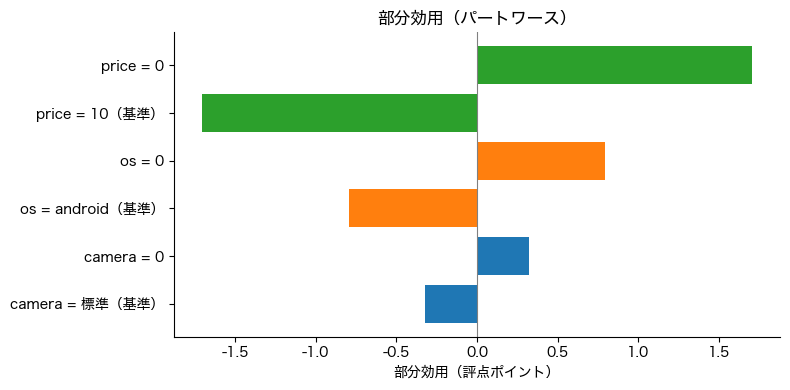

In [26]:
# plot_partworth — result メソッドとして呼ぶ
ax = result.plot_partworth(title="部分効用（パートワース）", show_zero_line=True)

Text(0.5, 1.0, 'pc.plot_partworth()（ゼロ線なし）')

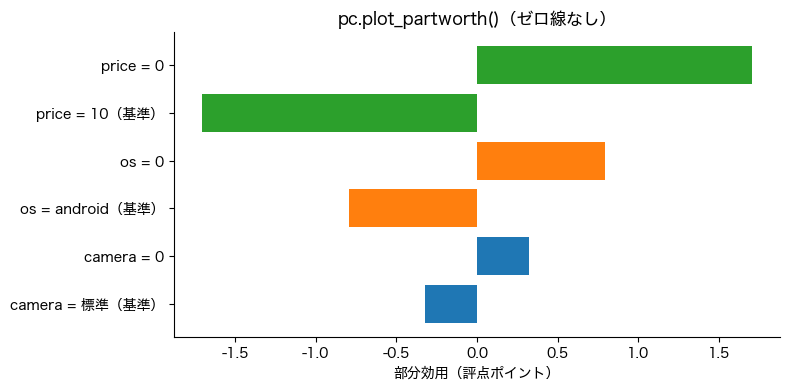

In [27]:
# plot_partworth — pc モジュールの関数として呼ぶ
ax = pcr.plot_partworth(result, show_zero_line=False)
ax.set_title("pcr.plot_partworth()（ゼロ線なし）")

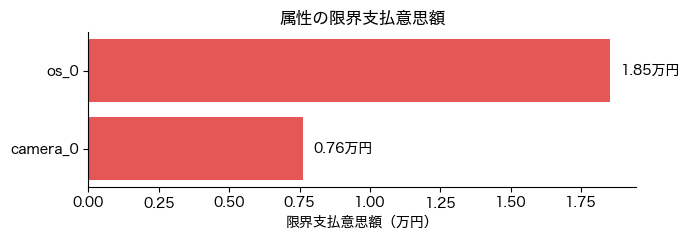

In [28]:
# plot_wtp — result メソッドとして呼ぶ
ax = result.plot_wtp(price_unit="万円", show_values=True, sort=True)

Text(0.5, 1.0, 'pc.plot_wtp()（ソートなし）')

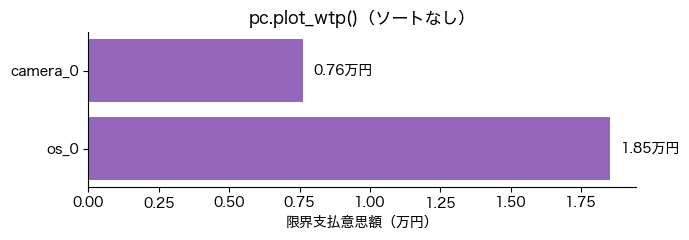

In [29]:
# plot_wtp — pc モジュールの関数として呼ぶ
ax = pcr.plot_wtp(result, price_unit="万円", color="#9467BD", sort=False)
ax.set_title("pcr.plot_wtp()（ソートなし）")